# Disability Progression in Multiple Sclerosis from EDSS Scores
This tutorial notebook demonstrates the usage of some key functions in this repository.

See ``methods.ipynb`` for visualizations of individual definition aspects & combinations thereof.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from definitions import edssannotation
from tools import evaluation_new_annotation_modes as evaluation
from tools import preprocessing  # , visualization
from tools import visualization_new_annotation_modes as visualization

sns.set_theme(color_codes=True)
sns.set_style("whitegrid", {"grid_color": "gainsboro"})

In [2]:
# This refreshes any modules upon change
%load_ext autoreload
%autoreload 2

## Input data format
* Data have to be provided as a Pandas dataframe, e.g. by importing an .xlsx or .csv file. 
* The data must have at least:
    * One column for the EDSS score
    * One column for the timestamp
* Relapses must be provided as a list of relapse timestamps.

See the example data in the *Single follow-up example* section.

### Important
* The timestamps must be provided as integers, e.g. as the numbers of days or weeks after baseline.
* The data have to be ordered in time from first to last assessment.
* The timestamps must be unique, i.e. there mustn't be two assessments with the same timestamp.

The section *A note on data preprocessing* shows an example workflow to convert lists of dates to the correct input format.

Note that the preprocessing is not part of the algorithm. The reason for this design choice is that
data provided in datetime format can be difficult to process when data quality is lacking, and potential
quality issues such as duplicates, inconsistent timestamps, or not well-ordered timestamps might require
the input of a subject matter expert for resolving.

## Single follow-up example

### Example data

In [3]:
example_follow_up_df = pd.DataFrame(
    [
        {"days_after_baseline": 0, "edss_score": 5.0},
        {"days_after_baseline": 10, "edss_score": 4.5},
        {"days_after_baseline": 20, "edss_score": 4.5},
        {"days_after_baseline": 30, "edss_score": 5.0},
        {"days_after_baseline": 40, "edss_score": 4.5},
        {"days_after_baseline": 50, "edss_score": 4.0},
        {"days_after_baseline": 60, "edss_score": 3.5},
        {"days_after_baseline": 70, "edss_score": 5.5},
        {"days_after_baseline": 80, "edss_score": 5.5},
        {"days_after_baseline": 90, "edss_score": 4.5},
    ]
)
example_relapse_timestamps = []

### Instantiate annotation class
See ``definitions.edssprogression.EDSSProgression`` for all available options and default values.

Examples for each option and some combinations of options are provided in ``methods.ipynb``.

In [4]:
Annot = edssannotation.EDSSAnnotation(
    annotation_mode="symmetric",
    undefined_events_annotation_mode="all",
    opt_baseline_type="fixed",
    # PIRA/RAW options - ignored if no relapses specified
    opt_raw_before_relapse_max_time=5,
    opt_raw_after_relapse_max_time=10,
    # Minimum increase options
    opt_max_score_that_requires_plus_1=5.0,
    # Confirmation options
    opt_require_confirmation=True,
    opt_confirmation_time=0.5,  # Next-confirmed
    # Input specifications
    edss_score_column_name="edss_score",
    time_column_name="days_after_baseline",
)

### Get the annotated events

In [5]:
Annot.add_event_annotation_to_follow_up(
    follow_up_dataframe=example_follow_up_df,
    relapse_timestamps=example_relapse_timestamps,
)

,days_after_baseline,edss_score,days_since_previous_relapse,days_to_next_relapse,is_post_event_rebaseline,is_general_rebaseline,is_pira_rebaseline,edss_score_used_as_new_general_reference,edss_score_used_as_new_pira_reference,is_event,is_accrual_event,is_improvement_event,event_type,event_score,event_reference_score,event_id,accrual_event_id,improvement_event_id,is_post_relapse_rebaseline
0,0,5.0,NaN,NaN,False,False,False,NaN,NaN,False,False,False,None,NaN,NaN,NaN,NaN,NaN,False
1,10,4.5,NaN,NaN,False,False,False,NaN,NaN,False,False,False,None,NaN,NaN,NaN,NaN,NaN,False
2,20,4.5,NaN,NaN,False,False,False,NaN,NaN,False,False,False,None,NaN,NaN,NaN,NaN,NaN,False
3,30,5.0,NaN,NaN,False,False,False,NaN,NaN,False,False,False,None,NaN,NaN,NaN,NaN,NaN,False
4,40,4.5,NaN,NaN,False,False,False,NaN,NaN,False,False,False,None,NaN,NaN,NaN,NaN,NaN,False
5,50,4.0,NaN,NaN,True,True,True,4.0,4.0,True,False,True,Improvement,4.0,5.0,1.0,NaN,1.0,False
6,60,3.5,NaN,NaN,False,False,False,NaN,NaN,False,False,False,None,NaN,NaN,NaN,NaN,NaN,False
7,70,5.5,NaN,NaN,True,True,True,5.5,5.5,True,True,False,PIRA,5.5,4.0,2.0,1.0,NaN,False
8,80,5.5,NaN,NaN,False,False,False,NaN,NaN,False,False,False,None,NaN,NaN,NaN,NaN,NaN,False
9,90,4.5,NaN,NaN,False,False,False,NaN,NaN,False,False,False,None,NaN,NaN,NaN,NaN,NaN,False


### Plot the follow-up with the annotated events
This function creates an instance of EDSSProgression, uses it to annotate the follow-up, and then visualizes the annotated follow-up.

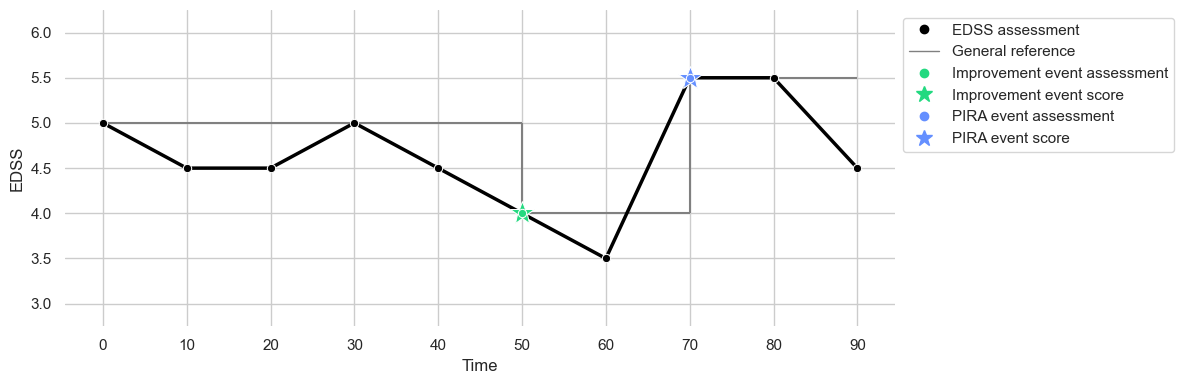

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up_df,
    relapse_timestamps=example_relapse_timestamps,
    # Options for EDSSProgression
    annotation_mode="symmetric",
    undefined_events_annotation_mode="all",
    opt_baseline_type="fixed",
    # PIRA/RAW options - ignored if no relapses specified
    opt_raw_before_relapse_max_time=5,
    opt_raw_after_relapse_max_time=10,
    # Minimum increase options
    opt_max_score_that_requires_plus_1=5.0,
    # Confirmation options
    opt_require_confirmation=True,
    opt_confirmation_time=0.5,  # Next-confirmed
    # Input specifications
    edss_score_column_name="edss_score",
    time_column_name="days_after_baseline",
    # Plot args
    ax=ax,
)
fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

### Add a relapse

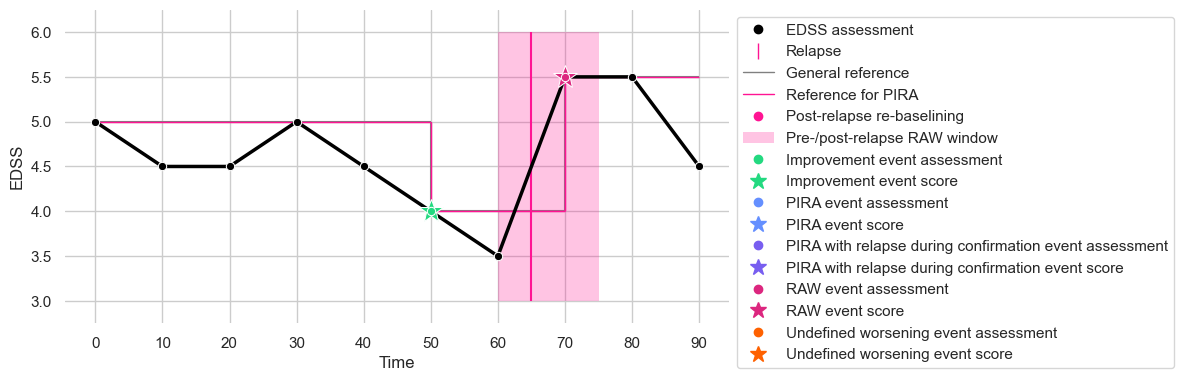

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up_df,
    relapse_timestamps=[65],
    # Options for EDSSProgression
    annotation_mode="symmetric",
    undefined_events_annotation_mode="all",
    opt_baseline_type="fixed",
    # PIRA/RAW options - ignored if no relapses specified
    opt_raw_before_relapse_max_time=5,
    opt_raw_after_relapse_max_time=10,
    # Minimum increase options
    opt_max_score_that_requires_plus_1=5.0,
    # Confirmation options
    opt_require_confirmation=True,
    opt_confirmation_time=0.5,  # Next-confirmed
    # Input specifications
    edss_score_column_name="edss_score",
    time_column_name="days_after_baseline",
    # Plot args
    ax=ax,
)
fig.tight_layout()
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

## Example from the Streamlit app

In [8]:
example_follow_up_df_2 = pd.DataFrame(
    [
        {"days_after_baseline": 0, "edss_score": 1.0},
        {"days_after_baseline": 60, "edss_score": 2.5},
        {"days_after_baseline": 90, "edss_score": 1.5},
        {"days_after_baseline": 150, "edss_score": 2.0},
        {"days_after_baseline": 220, "edss_score": 3.5},
        {"days_after_baseline": 250, "edss_score": 2.0},
        {"days_after_baseline": 310, "edss_score": 2.0},
        {"days_after_baseline": 350, "edss_score": 4.0},
        {"days_after_baseline": 380, "edss_score": 3.5},
        {"days_after_baseline": 420, "edss_score": 3.5},
        {"days_after_baseline": 480, "edss_score": 2.5},
        {"days_after_baseline": 540, "edss_score": 2.5},
        {"days_after_baseline": 600, "edss_score": 3.5},
        {"days_after_baseline": 660, "edss_score": 4.0},
        {"days_after_baseline": 720, "edss_score": 4.5},
        {"days_after_baseline": 780, "edss_score": 5.0},
        {"days_after_baseline": 840, "edss_score": 5.0},
        {"days_after_baseline": 900, "edss_score": 5.0},
    ]
)
example_relapse_timestamps_2 = [40, 200, 330, 770]

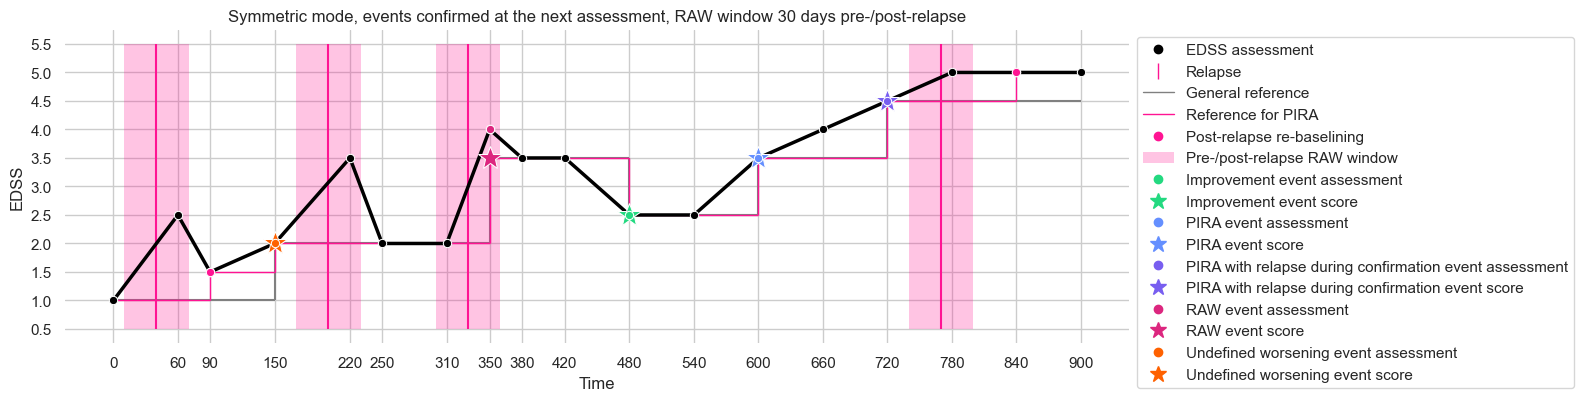

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(16, 4))
visualization.annotate_plot_follow_up(
    follow_up_dataframe=example_follow_up_df_2,
    relapse_timestamps=example_relapse_timestamps_2,
    # Options for EDSSProgression
    annotation_mode="symmetric",
    undefined_events_annotation_mode="all",
    opt_baseline_type="fixed",
    # PIRA/RAW options - ignored if no relapses specified
    opt_raw_before_relapse_max_time=30,
    opt_raw_after_relapse_max_time=30,
    # Minimum increase options
    opt_max_score_that_requires_plus_1=5.0,
    # Confirmation options
    opt_require_confirmation=True,
    opt_confirmation_time=0.5,  # Next-confirmed
    # Plot args
    ax=ax,
)
fig.tight_layout()
ax.set_title(
    "Symmetric mode, events confirmed at the next assessment, RAW window 30 days pre-/post-relapse"
)
sns.despine(bottom=True, left=True, right=True, top=True)
plt.show()

## Evaluate annotated follow-ups

### Instantiate the evaluation class
Since we used the default column names from the annotation class, we don't need to supply any arguments.

In [10]:
Eval = evaluation.EDSSAnnotationEvaluation()

### Individual follow-up
Annotate the events in the example dataframes first.

#### First example

In [11]:
example_follow_up_df_annotated = Annot.add_event_annotation_to_follow_up(
    follow_up_dataframe=example_follow_up_df,
    relapse_timestamps=example_relapse_timestamps,
)

#### Streamlit example

In [12]:
example_follow_up_df_2_annotated = edssannotation.EDSSAnnotation(
    annotation_mode="symmetric",
    undefined_events_annotation_mode="all",
    opt_baseline_type="fixed",
    opt_raw_before_relapse_max_time=30,
    opt_raw_after_relapse_max_time=30,
    opt_max_score_that_requires_plus_1=5.0,
    opt_require_confirmation=True,
    opt_confirmation_time=0.5,
).add_event_annotation_to_follow_up(
    follow_up_dataframe=example_follow_up_df_2,
    relapse_timestamps=example_relapse_timestamps_2,
)

#### Get follow-up level stats overall
Duration of follow-up, total events irrespective of type, total delta EDSS irrespective of type, first event irrespective of type

##### First example

In [13]:
Eval.get_follow_up_stats(
    annotated_follow_ups=example_follow_up_df_annotated,
    get_stats_by_type=False,
    id_columns=None,
)

,first_timestamp,last_timestamp,duration_of_follow_up,total_events,total_event_score_delta,total_accrual_events,total_accrual_event_score_delta,total_improvement_events,total_improvement_event_score_delta,first_event_days_after_baseline,...,first_accrual_event_days_after_baseline,first_accrual_event_event_reference_score,first_accrual_event_event_score,first_accrual_event_event_score_delta,first_accrual_event_event_type,first_improvement_event_days_after_baseline,first_improvement_event_event_reference_score,first_improvement_event_event_score,first_improvement_event_event_score_delta,first_improvement_event_event_type
0,0,90,90,2,0.5,1,1.5,1,-1.0,50,...,70,4.0,5.5,1.5,PIRA,50,5.0,4.0,-1.0,Improvement


##### Streamlit example

In [14]:
Eval.get_follow_up_stats(
    annotated_follow_ups=example_follow_up_df_2_annotated,
    get_stats_by_type=False,
    id_columns=None,
)

,first_timestamp,last_timestamp,duration_of_follow_up,total_events,total_event_score_delta,total_accrual_events,total_accrual_event_score_delta,total_improvement_events,total_improvement_event_score_delta,first_event_days_after_baseline,...,first_accrual_event_days_after_baseline,first_accrual_event_event_reference_score,first_accrual_event_event_score,first_accrual_event_event_score_delta,first_accrual_event_event_type,first_improvement_event_days_after_baseline,first_improvement_event_event_reference_score,first_improvement_event_event_score,first_improvement_event_event_score_delta,first_improvement_event_event_type
0,0,900,900,5,3.5,4,4.5,1,-1.0,150,...,150,1.0,2.0,1.0,Undefined,480,3.5,2.5,-1.0,Improvement


#### Get follow-up level stats by type
Duration of follow-up, total events by type, total delta EDSS by type, first event by type

##### First example

In [15]:
Eval.get_follow_up_stats(
    annotated_follow_ups=example_follow_up_df_annotated,
    get_stats_by_type=True,
    id_columns=None,
)

,first_timestamp,last_timestamp,duration_of_follow_up,event_type,total_events,total_event_score_delta,first_event_days_after_baseline,first_event_event_reference_score,first_event_event_score,first_event_event_score_delta
0,0,90,90,PIRA,1,1.5,70.0,4.0,5.5,1.5
1,0,90,90,PIRA with relapse during confirmation,0,0.0,NaN,NaN,NaN,NaN
2,0,90,90,RAW,0,0.0,NaN,NaN,NaN,NaN
3,0,90,90,Undefined,0,0.0,NaN,NaN,NaN,NaN
4,0,90,90,Improvement,1,-1.0,50.0,5.0,4.0,-1.0


##### Streamlit example

In [16]:
Eval.get_follow_up_stats(
    annotated_follow_ups=example_follow_up_df_2_annotated,
    get_stats_by_type=True,
    id_columns=None,
)

,first_timestamp,last_timestamp,duration_of_follow_up,event_type,total_events,total_event_score_delta,first_event_days_after_baseline,first_event_event_reference_score,first_event_event_score,first_event_event_score_delta
0,0,900,900,PIRA,1,1.0,600,2.5,3.5,1.0
1,0,900,900,PIRA with relapse during confirmation,1,1.0,720,3.5,4.5,1.0
2,0,900,900,RAW,1,1.5,350,2.0,3.5,1.5
3,0,900,900,Undefined,1,1.0,150,1.0,2.0,1.0
4,0,900,900,Improvement,1,-1.0,480,3.5,2.5,-1.0


### Multiple follow-ups

Concatenate the dataframes we have and **add an ID for each follow-up**.

In [17]:
multiple_follow_ups_annotated = pd.concat(
    [
        example_follow_up_df_annotated.assign(follow_up_id=1),
        example_follow_up_df_2_annotated.assign(follow_up_id=2),
    ]
)

#### Get follow-up level stats overall
Duration of follow-up, total events irrespective of type, total delta EDSS irrespective of type, first event irrespective of type for each follow-up

In [18]:
Eval.get_follow_up_stats(
    annotated_follow_ups=multiple_follow_ups_annotated,
    get_stats_by_type=False,
    id_columns=["follow_up_id"],
)

,follow_up_id,first_timestamp,last_timestamp,duration_of_follow_up,total_events,total_event_score_delta,total_accrual_events,total_accrual_event_score_delta,total_improvement_events,total_improvement_event_score_delta,...,first_accrual_event_days_after_baseline,first_accrual_event_event_reference_score,first_accrual_event_event_score,first_accrual_event_event_score_delta,first_accrual_event_event_type,first_improvement_event_days_after_baseline,first_improvement_event_event_reference_score,first_improvement_event_event_score,first_improvement_event_event_score_delta,first_improvement_event_event_type
0,1,0,90,90,2,0.5,1,1.5,1,-1.0,...,70,4.0,5.5,1.5,PIRA,50,5.0,4.0,-1.0,Improvement
1,2,0,900,900,5,3.5,4,4.5,1,-1.0,...,150,1.0,2.0,1.0,Undefined,480,3.5,2.5,-1.0,Improvement


#### Get follow-up level stats by type
Duration of follow-up, total events by type, total delta EDSS by type, first event by type for each follow-up

In [19]:
Eval.get_follow_up_stats(
    annotated_follow_ups=multiple_follow_ups_annotated,
    get_stats_by_type=True,
    id_columns=["follow_up_id"],
)

,follow_up_id,first_timestamp,last_timestamp,duration_of_follow_up,event_type,total_events,total_event_score_delta,first_event_days_after_baseline,first_event_event_reference_score,first_event_event_score,first_event_event_score_delta
0,1,0,90,90,PIRA,1,1.5,70.0,4.0,5.5,1.5
1,1,0,90,90,PIRA with relapse during confirmation,0,0.0,NaN,NaN,NaN,NaN
2,1,0,90,90,RAW,0,0.0,NaN,NaN,NaN,NaN
3,1,0,90,90,Undefined,0,0.0,NaN,NaN,NaN,NaN
4,1,0,90,90,Improvement,1,-1.0,50.0,5.0,4.0,-1.0
5,2,0,900,900,PIRA,1,1.0,600.0,2.5,3.5,1.0
6,2,0,900,900,PIRA with relapse during confirmation,1,1.0,720.0,3.5,4.5,1.0
7,2,0,900,900,RAW,1,1.5,350.0,2.0,3.5,1.5
8,2,0,900,900,Undefined,1,1.0,150.0,1.0,2.0,1.0
9,2,0,900,900,Improvement,1,-1.0,480.0,3.5,2.5,-1.0


#### Add more example follow-ups
With accrual only, with improvement only, without events

In [20]:
multiple_follow_ups_annotated_extended = pd.concat(
    [
        multiple_follow_ups_annotated,
        Annot.add_event_annotation_to_follow_up(
            follow_up_dataframe=pd.DataFrame(
                [
                    {"days_after_baseline": 0, "edss_score": 5.0},
                    {"days_after_baseline": 10, "edss_score": 4.5},
                    {"days_after_baseline": 20, "edss_score": 4.5},
                    {"days_after_baseline": 30, "edss_score": 5.0},
                    {"days_after_baseline": 40, "edss_score": 4.5},
                    {"days_after_baseline": 50, "edss_score": 4.0},
                    {"days_after_baseline": 60, "edss_score": 3.5},
                ]
            ),
            relapse_timestamps=[],
        ).assign(follow_up_id=3),
        Annot.add_event_annotation_to_follow_up(
            follow_up_dataframe=pd.DataFrame(
                [
                    {"days_after_baseline": 0, "edss_score": 3.5},
                    {"days_after_baseline": 10, "edss_score": 4.0},
                    {"days_after_baseline": 20, "edss_score": 4.5},
                    {"days_after_baseline": 30, "edss_score": 5.0},
                    {"days_after_baseline": 40, "edss_score": 4.5},
                    {"days_after_baseline": 50, "edss_score": 4.5},
                    {"days_after_baseline": 60, "edss_score": 5.5},
                ]
            ),
            relapse_timestamps=[],
        ).assign(follow_up_id=4),
        Annot.add_event_annotation_to_follow_up(
            follow_up_dataframe=pd.DataFrame(
                [
                    {"days_after_baseline": 0, "edss_score": 3.5},
                    {"days_after_baseline": 10, "edss_score": 4.0},
                    {"days_after_baseline": 20, "edss_score": 4.0},
                    {"days_after_baseline": 30, "edss_score": 4.0},
                ]
            ),
            relapse_timestamps=[],
        ).assign(follow_up_id=5),
    ]
)

In [21]:
Eval.get_follow_up_stats(
    annotated_follow_ups=multiple_follow_ups_annotated_extended,
    get_stats_by_type=False,
    id_columns=["follow_up_id"],
)

,follow_up_id,first_timestamp,last_timestamp,duration_of_follow_up,total_events,total_event_score_delta,total_accrual_events,total_accrual_event_score_delta,total_improvement_events,total_improvement_event_score_delta,...,first_accrual_event_days_after_baseline,first_accrual_event_event_reference_score,first_accrual_event_event_score,first_accrual_event_event_score_delta,first_accrual_event_event_type,first_improvement_event_days_after_baseline,first_improvement_event_event_reference_score,first_improvement_event_event_score,first_improvement_event_event_score_delta,first_improvement_event_event_type
0,1,0,90,90,2,0.5,1,1.5,1,-1.0,...,70.0,4.0,5.5,1.5,PIRA,50.0,5.0,4.0,-1.0,Improvement
1,2,0,900,900,5,3.5,4,4.5,1,-1.0,...,150.0,1.0,2.0,1.0,Undefined,480.0,3.5,2.5,-1.0,Improvement
2,3,0,60,60,1,-1.0,0,0.0,1,-1.0,...,NaN,NaN,NaN,NaN,NaN,50.0,5.0,4.0,-1.0,Improvement
3,4,0,60,60,1,1.0,1,1.0,0,0.0,...,20.0,3.5,4.5,1.0,PIRA,NaN,NaN,NaN,NaN,NaN
4,5,0,30,30,0,0.0,0,0.0,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Multiple follow-ups, cohort level stats

#### Get cohort level stats overall
Number of follow-ups, events overall, follow-ups with events, total EDSS delta overall, proportion of follow-ups with at least one event irrespective of type, median time to first event

In [22]:
Eval.get_cohort_stats(
    stats_by_follow_up=Eval.get_follow_up_stats(
        annotated_follow_ups=multiple_follow_ups_annotated_extended,
        get_stats_by_type=False,
        id_columns=["follow_up_id"],
    ),
    get_stats_by_type=False,
    follow_up_id_column="follow_up_id",
    groupby_columns=None,
).T

,0
n_follow_ups,5.000000
total_events,9.000000
total_accrual_events,6.000000
total_improvement_events,3.000000
total_event_score_delta,4.000000
total_accrual_event_score_delta,7.000000
total_improvement_event_score_delta,-3.000000
contribution_of_accrual_to_total_events,0.666667
contribution_of_improvement_to_total_events,0.333333
n_follow_ups_with_events,4.000000


#### Get follow-up level stats by type
Number of follow-ups, events by type, follow-ups with events by type, total EDSS delta by type, proportion of follow-ups with at least one event of a given type, median time to first event of a given type, contribution of a given type to total events and total EDSS delta

In [23]:
Eval.get_cohort_stats(
    stats_by_follow_up=Eval.get_follow_up_stats(
        annotated_follow_ups=multiple_follow_ups_annotated,
        get_stats_by_type=True,
        id_columns=["follow_up_id"],
    ),
    get_stats_by_type=True,
    follow_up_id_column="follow_up_id",
    groupby_columns=None,
)

,event_type,n_follow_ups,total_events,total_event_score_delta,contribution_to_total_events,contribution_to_total_delta,contribution_to_total_accrual_events,contribution_to_total_accrual_delta,contribution_to_total_improvement_events,contribution_to_total_improvement_delta,n_follow_ups_with_events,n_follow_ups_with_events_relative,n_follow_ups_without_events,median_time_to_first_event,median_time_to_first_event_lower_95CI,median_time_to_first_event_upper_95CI
0,Improvement,2,2,-2.0,0.285714,-0.500,NaN,NaN,1.0,1.0,2,1.0,0,50.0,50.0,480.0
1,PIRA,2,2,2.5,0.285714,0.625,0.4,0.416667,NaN,NaN,2,1.0,0,70.0,70.0,600.0
2,PIRA with relapse during confirmation,2,1,1.0,0.142857,0.250,0.2,0.166667,NaN,NaN,1,0.5,1,720.0,720.0,720.0
3,RAW,2,1,1.5,0.142857,0.375,0.2,0.250000,NaN,NaN,1,0.5,1,350.0,350.0,350.0
4,Undefined,2,1,1.0,0.142857,0.250,0.2,0.166667,NaN,NaN,1,0.5,1,150.0,150.0,150.0


In [24]:
Eval.get_cohort_stats(
    stats_by_follow_up=Eval.get_follow_up_stats(
        annotated_follow_ups=multiple_follow_ups_annotated_extended,
        get_stats_by_type=True,
        id_columns=["follow_up_id"],
    ),
    get_stats_by_type=True,
    follow_up_id_column="follow_up_id",
    groupby_columns=None,
)

,event_type,n_follow_ups,total_events,total_event_score_delta,contribution_to_total_events,contribution_to_total_delta,contribution_to_total_accrual_events,contribution_to_total_accrual_delta,contribution_to_total_improvement_events,contribution_to_total_improvement_delta,n_follow_ups_with_events,n_follow_ups_with_events_relative,n_follow_ups_without_events,median_time_to_first_event,median_time_to_first_event_lower_95CI,median_time_to_first_event_upper_95CI
0,Improvement,5,3,-3.0,0.333333,-0.750,NaN,NaN,1.0,1.0,3,0.6,2,50.0,50.0,480.0
1,PIRA,5,3,3.5,0.333333,0.875,0.500000,0.500000,NaN,NaN,3,0.6,2,70.0,20.0,600.0
2,PIRA with relapse during confirmation,5,1,1.0,0.111111,0.250,0.166667,0.142857,NaN,NaN,1,0.2,4,720.0,720.0,720.0
3,RAW,5,1,1.5,0.111111,0.375,0.166667,0.214286,NaN,NaN,1,0.2,4,350.0,350.0,350.0
4,Undefined,5,1,1.0,0.111111,0.250,0.166667,0.142857,NaN,NaN,1,0.2,4,150.0,150.0,150.0


### Get stats for event type combinations

In [25]:
with pd.option_context("display.max_colwidth", 400):
    display(
        Eval.get_combination_stats(
            stats_by_follow_up=Eval.get_follow_up_stats(
                annotated_follow_ups=multiple_follow_ups_annotated,
                get_stats_by_type=True,
                id_columns=["follow_up_id"],
            ),
            follow_up_id_column="follow_up_id",
            groupby_columns=None,
        )
    )

,combination_query,n_follow_ups,n_follow_ups_relative,of_follow_ups_with_events
0,(`PIRA` > 0) and (`PIRA with relapse during confirmation` == 0) and (`RAW` == 0) and (`Undefined` == 0) and (`Improvement` == 0),0,0.0,0.0
1,(`PIRA with relapse during confirmation` > 0) and (`PIRA` == 0) and (`RAW` == 0) and (`Undefined` == 0) and (`Improvement` == 0),0,0.0,0.0
2,(`RAW` > 0) and (`PIRA` == 0) and (`PIRA with relapse during confirmation` == 0) and (`Undefined` == 0) and (`Improvement` == 0),0,0.0,0.0
3,(`Undefined` > 0) and (`PIRA` == 0) and (`PIRA with relapse during confirmation` == 0) and (`RAW` == 0) and (`Improvement` == 0),0,0.0,0.0
4,(`Improvement` > 0) and (`PIRA` == 0) and (`PIRA with relapse during confirmation` == 0) and (`RAW` == 0) and (`Undefined` == 0),0,0.0,0.0
...,...,...,...,...
56,(`PIRA` > 0) and (`PIRA with relapse during confirmation` > 0) and (`RAW` > 0) and (`Improvement` > 0),1,0.5,0.5
57,(`PIRA` > 0) and (`PIRA with relapse during confirmation` > 0) and (`Undefined` > 0) and (`Improvement` > 0),1,0.5,0.5
58,(`PIRA` > 0) and (`RAW` > 0) and (`Undefined` > 0) and (`Improvement` > 0),1,0.5,0.5
59,(`PIRA with relapse during confirmation` > 0) and (`RAW` > 0) and (`Undefined` > 0) and (`Improvement` > 0),1,0.5,0.5


# A note on data preprocessing

Note that data preprocessing (from datetime to integer unit after baseline)
is not part of the EDSS disability accrual annotation algorithm, since it
can be tricky if source data are of low quality (inconsistent datetime formats,
duplicate entries, not ordered properly...). 

The functions in the ``peprocessing`` module are meant as an **example** of how to 
do the preprocessing, and they are built to just throw errors if the input data 
do not satisfy some minimal formatting requirements. They do not try to fix anything, 
they don't even re-order data, you will have to take care of this.

## Example data
Data will usually be provided as a table with dates and scores, therefore
some preprocessing is required. Each raw follow-up needs to have an ID.

### EDSS scores

In [26]:
start_date = pd.Timestamp(year=2000, month=1, day=1)

In [27]:
example_data = pd.concat(
    [
        pd.DataFrame(
            {
                "follow_up_id": [0 for _ in range(10)],
                "date": [
                    start_date + pd.Timedelta(i * 10, unit="days") for i in range(10)
                ],
                "edss_score": [1.0 + 0.5 * i for i in range(10)],
            }
        ),
        pd.DataFrame(
            {
                "follow_up_id": [1 for _ in range(9)],
                "date": [
                    start_date + pd.Timedelta(i * 10, unit="days") for i in range(5)
                ]
                + [start_date + pd.Timedelta(i * 10, unit="days") for i in range(6, 7)]
                + [
                    start_date + pd.Timedelta((i + 1) * 10, unit="days")
                    for i in range(7, 10)
                ],
                "edss_score": [1.0 + 0.5 * i for i in range(9)],
            }
        ),
    ]
).reset_index(drop=True)

In [28]:
example_data

,follow_up_id,date,edss_score
0,0,2000-01-01,1.0
1,0,2000-01-11,1.5
2,0,2000-01-21,2.0
3,0,2000-01-31,2.5
4,0,2000-02-10,3.0
5,0,2000-02-20,3.5
6,0,2000-03-01,4.0
7,0,2000-03-11,4.5
8,0,2000-03-21,5.0
9,0,2000-03-31,5.5


### Relapses

In [29]:
example_relapses = pd.concat(
    [
        pd.DataFrame(
            {
                "follow_up_id": [0, 0, 0],
                "date": [
                    pd.Timestamp(year=1999, month=12, day=1),
                    pd.Timestamp(year=2000, month=2, day=20),
                    pd.Timestamp(year=2000, month=12, day=1),
                ],
            }
        ),
        pd.DataFrame(
            {
                "follow_up_id": [1, 1, 1],
                "date": [
                    pd.Timestamp(year=1999, month=12, day=5),
                    pd.Timestamp(year=2000, month=2, day=25),
                    pd.Timestamp(year=2000, month=12, day=5),
                ],
            }
        ),
    ]
).reset_index(drop=True)

In [30]:
example_relapses

,follow_up_id,date
0,0,1999-12-01
1,0,2000-02-20
2,0,2000-12-01
3,1,1999-12-05
4,1,2000-02-25
5,1,2000-12-05


## Quality checks
The function ``check_input_date_data`` in the ``preprocessing`` module can be used to detect problems with input data.

### Follow-ups

In [31]:
for follow_up_id in example_data["follow_up_id"].drop_duplicates():
    print("\nFollow-up", follow_up_id, "\n")
    preprocessing.check_input_date_data(
        input_dataframe=example_data[example_data["follow_up_id"] == follow_up_id],
        date_column_name="date",
        verbose=True,
    )


Follow-up 0 

Check date format.
Date only, proceed.

Check order and uniqueness of timestamps.
Unique and well ordered.

Follow-up 1 

Check date format.
Date only, proceed.

Check order and uniqueness of timestamps.
Unique and well ordered.


### Relapses

In [32]:
for follow_up_id in example_relapses["follow_up_id"].drop_duplicates():
    print("\nFollow-up", follow_up_id, "\n")
    preprocessing.check_input_date_data(
        input_dataframe=example_relapses[
            example_relapses["follow_up_id"] == follow_up_id
        ],
        date_column_name="date",
        verbose=True,
    )


Follow-up 0 

Check date format.
Date only, proceed.

Check order and uniqueness of timestamps.
Unique and well ordered.

Follow-up 1 

Check date format.
Date only, proceed.

Check order and uniqueness of timestamps.
Unique and well ordered.


### Examples of well- and ill-formatted data

In [33]:
# Monotonically increasing, no time part
preprocessing.check_input_date_data(
    input_dataframe=pd.DataFrame(
        {
            "date": [
                pd.Timestamp(year=2000, month=1, day=1),
                pd.Timestamp(year=2000, month=1, day=2),
            ]
        }
    ),
    date_column_name="date",
    verbose=True,
)

Check date format.
Date only, proceed.

Check order and uniqueness of timestamps.
Unique and well ordered.


#### Ill-formatted timestamps

In [ ]:
# Time part in timestamp raises ValueError
preprocessing.check_input_date_data(
    input_dataframe=pd.DataFrame(
        {
            "date": [
                pd.Timestamp(year=2000, month=1, day=1, hour=12),
                pd.Timestamp(year=2000, month=1, day=2),
            ]
        }
    ),
    date_column_name="date",
    verbose=True,
)

#### Duplicate timestamps

In [ ]:
# Duplicate timestamp raises ValueError
preprocessing.check_input_date_data(
    input_dataframe=pd.DataFrame(
        {
            "date": [
                pd.Timestamp(year=2000, month=1, day=1),
                pd.Timestamp(year=2000, month=1, day=1),
            ]
        }
    ),
    date_column_name="date",
    verbose=True,
)

#### Timestamps not ordered

In [ ]:
# Non-monotonically increasing timestamps raise ValueError
preprocessing.check_input_date_data(
    input_dataframe=pd.DataFrame(
        {
            "date": [
                pd.Timestamp(year=2000, month=1, day=2),
                pd.Timestamp(year=2000, month=1, day=1),
            ]
        }
    ),
    date_column_name="date",
    verbose=True,
)

## Preprocess follow-ups

### One single follow-up
The function ``find_connected_blocks`` adds IDs of connected blocks to an input dataframe.

Runs the quality check on each follow-up, so if one of them is not well-formatted,
it will throw an error.

Assessments that are not part of a connected follow-up block have no block ID.

For each block, the integer timestamp column starts at 0.

In [34]:
preprocessing.find_connected_blocks(
    input_dataframe=example_data.query("follow_up_id == 1"),
    max_days_between_timestamps=10,
    min_days_overall=20,
    min_n_timestamps=0,
    date_column_name="date",
    block_id_start=0,
    block_id_column_name="block_id",
    block_baseline_flag_column_name="is_block_baseline",
    days_after_baseline_column_name="days_after_baseline",
    tests_verbose=False,
)

,follow_up_id,date,edss_score,block_id,is_block_baseline,days_after_baseline
10,1,2000-01-01,1.0,0.0,True,0.0
11,1,2000-01-11,1.5,0.0,False,10.0
12,1,2000-01-21,2.0,0.0,False,20.0
13,1,2000-01-31,2.5,0.0,False,30.0
14,1,2000-02-10,3.0,0.0,False,40.0
15,1,2000-03-01,3.5,NaN,False,NaN
16,1,2000-03-21,4.0,1.0,True,0.0
17,1,2000-03-31,4.5,1.0,False,10.0
18,1,2000-04-10,5.0,1.0,False,20.0


### A dataframe with multiple follow ups
The function ``prepare_follow_ups`` returns all connected follow-up blocks, and drops assessments that are not part of a connected follow-up.

Runs the quality check on each follow-up, so if one of them is not well-formatted,
it will throw an error.

The block IDs are unique over the entire dataframe.

In [35]:
preprocessing.prepare_follow_ups(
    follow_ups_dataframe=example_data,
    max_days_between_timestamps=10,
    min_days_overall=20,
    min_n_timestamps=0,
    id_column_name="follow_up_id",
    date_column_name="date",
    days_after_baseline_column_name="days_after_baseline",
)

,follow_up_id,date,edss_score,block_id,is_block_baseline,days_after_baseline
0,0,2000-01-01,1.0,0,True,0
1,0,2000-01-11,1.5,0,False,10
2,0,2000-01-21,2.0,0,False,20
3,0,2000-01-31,2.5,0,False,30
4,0,2000-02-10,3.0,0,False,40
5,0,2000-02-20,3.5,0,False,50
6,0,2000-03-01,4.0,0,False,60
7,0,2000-03-11,4.5,0,False,70
8,0,2000-03-21,5.0,0,False,80
9,0,2000-03-31,5.5,0,False,90


## Sync and preprocess relapses
Requires the processed follow-ups as input. Works on single and multiple follow-ups.

Runs quality checks on the relapses dataframe.

In [36]:
preprocessing.sync_relapse_data_to_follow_ups(
    preprocessed_follow_ups_dataframe=preprocessing.prepare_follow_ups(
        follow_ups_dataframe=example_data,
        max_days_between_timestamps=10,
        min_days_overall=20,
        min_n_timestamps=0,
        id_column_name="follow_up_id",
        date_column_name="date",
        days_after_baseline_column_name="days_after_baseline",
    ),
    relapses_dataframe=example_relapses,
    id_column_name="follow_up_id",
    date_column_name="date",
    days_after_baseline_column_name="days_after_baseline",
    block_baseline_flag_column_name="is_block_baseline",
)

,follow_up_id,block_baseline_date,edss_score,block_id,relapse_date,days_after_baseline
0,0,2000-01-01,1.0,0,1999-12-01,-31
1,0,2000-01-01,1.0,0,2000-02-20,50
2,0,2000-01-01,1.0,0,2000-12-01,335
3,1,2000-01-01,1.0,1,1999-12-05,-27
4,1,2000-01-01,1.0,1,2000-02-25,55
5,1,2000-01-01,1.0,1,2000-12-05,339
6,1,2000-03-21,4.0,2,1999-12-05,-107
7,1,2000-03-21,4.0,2,2000-02-25,-25
8,1,2000-03-21,4.0,2,2000-12-05,259


## Full workflow - use preprocessed data as input for annotation

In [37]:
preprocessed_follow_ups = preprocessing.prepare_follow_ups(
    follow_ups_dataframe=example_data,
    max_days_between_timestamps=10,
    min_days_overall=20,
    min_n_timestamps=0,
    id_column_name="follow_up_id",
    date_column_name="date",
    days_after_baseline_column_name="days_after_baseline",
)

In [38]:
preprocessed_relapses = preprocessing.sync_relapse_data_to_follow_ups(
    preprocessed_follow_ups_dataframe=preprocessed_follow_ups,
    relapses_dataframe=example_relapses,
    id_column_name="follow_up_id",
    date_column_name="date",
    days_after_baseline_column_name="days_after_baseline",
    block_baseline_flag_column_name="is_block_baseline",
)

In [39]:
preprocessed_follow_ups.head()

,follow_up_id,date,edss_score,block_id,is_block_baseline,days_after_baseline
0,0,2000-01-01,1.0,0,True,0
1,0,2000-01-11,1.5,0,False,10
2,0,2000-01-21,2.0,0,False,20
3,0,2000-01-31,2.5,0,False,30
4,0,2000-02-10,3.0,0,False,40


In [40]:
preprocessed_relapses.head()

,follow_up_id,block_baseline_date,edss_score,block_id,relapse_date,days_after_baseline
0,0,2000-01-01,1.0,0,1999-12-01,-31
1,0,2000-01-01,1.0,0,2000-02-20,50
2,0,2000-01-01,1.0,0,2000-12-01,335
3,1,2000-01-01,1.0,1,1999-12-05,-27
4,1,2000-01-01,1.0,1,2000-02-25,55


#### Run the annotation algorithm

In [41]:
annotated_follow_ups = []
for block_id in preprocessed_follow_ups["block_id"].drop_duplicates():
    annotated_follow_ups = annotated_follow_ups + [
        Annot.add_event_annotation_to_follow_up(
            follow_up_dataframe=preprocessed_follow_ups[
                preprocessed_follow_ups["block_id"] == block_id
            ],
            relapse_timestamps=list(
                preprocessed_relapses[preprocessed_relapses["block_id"] == block_id][
                    "days_after_baseline"
                ]
            ),
        )
    ]
annotated_follow_ups = pd.concat(annotated_follow_ups).reset_index(drop=True)

In [42]:
annotated_follow_ups.head()

,days_after_baseline,follow_up_id,date,edss_score,block_id,is_block_baseline,days_since_previous_relapse,days_to_next_relapse,is_post_event_rebaseline,is_general_rebaseline,...,is_event,is_accrual_event,is_improvement_event,event_type,event_score,event_reference_score,event_id,accrual_event_id,improvement_event_id,is_post_relapse_rebaseline
0,0,0,2000-01-01,1.0,0,True,31,50,False,False,...,False,False,False,None,NaN,NaN,NaN,NaN,NaN,True
1,10,0,2000-01-11,1.5,0,False,41,40,False,False,...,False,False,False,None,NaN,NaN,NaN,NaN,NaN,False
2,20,0,2000-01-21,2.0,0,False,51,30,True,True,...,True,True,False,PIRA,2.0,1.0,1.0,1.0,NaN,False
3,30,0,2000-01-31,2.5,0,False,61,20,False,False,...,False,False,False,None,NaN,NaN,NaN,NaN,NaN,False
4,40,0,2000-02-10,3.0,0,False,71,10,True,True,...,True,True,False,PIRA with relapse during confirmation,3.0,2.0,2.0,2.0,NaN,False


#### Evaluation on follow-up level

##### Overall

In [43]:
Eval.get_follow_up_stats(
    annotated_follow_ups=annotated_follow_ups,
    get_stats_by_type=False,
    id_columns=["follow_up_id", "block_id"],
)

,follow_up_id,block_id,first_timestamp,last_timestamp,duration_of_follow_up,total_events,total_event_score_delta,total_accrual_events,total_accrual_event_score_delta,total_improvement_events,...,first_accrual_event_days_after_baseline,first_accrual_event_event_reference_score,first_accrual_event_event_score,first_accrual_event_event_score_delta,first_accrual_event_event_type,first_improvement_event_days_after_baseline,first_improvement_event_event_reference_score,first_improvement_event_event_score,first_improvement_event_event_score_delta,first_improvement_event_event_type
0,0,0,0,90,90,4,4.0,4,4.0,0,...,20.0,1.0,2.0,1.0,PIRA,NaN,NaN,NaN,NaN,NaN
1,1,1,0,40,40,1,1.0,1,1.0,0,...,20.0,1.0,2.0,1.0,PIRA,NaN,NaN,NaN,NaN,NaN
2,1,2,0,20,20,0,0.0,0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### By type

In [44]:
Eval.get_follow_up_stats(
    annotated_follow_ups=annotated_follow_ups,
    get_stats_by_type=True,
    id_columns=["follow_up_id", "block_id"],
).head()

,follow_up_id,block_id,first_timestamp,last_timestamp,duration_of_follow_up,event_type,total_events,total_event_score_delta,first_event_days_after_baseline,first_event_event_reference_score,first_event_event_score,first_event_event_score_delta
0,0,0,0,90,90,PIRA,1,1.0,20.0,1.0,2.0,1.0
1,0,0,0,90,90,PIRA with relapse during confirmation,1,1.0,40.0,2.0,3.0,1.0
2,0,0,0,90,90,RAW,1,1.0,60.0,3.0,4.0,1.0
3,0,0,0,90,90,Undefined,1,1.0,80.0,4.0,5.0,1.0
4,0,0,0,90,90,Improvement,0,0.0,NaN,NaN,NaN,NaN


#### Evaluation on cohort level

##### Overall

In [45]:
Eval.get_cohort_stats(
    stats_by_follow_up=Eval.get_follow_up_stats(
        annotated_follow_ups=annotated_follow_ups,
        get_stats_by_type=False,
        id_columns=["follow_up_id", "block_id"],
    ),
    get_stats_by_type=False,
    follow_up_id_column="block_id",
    groupby_columns=None,
)

,n_follow_ups,total_events,total_accrual_events,total_improvement_events,total_event_score_delta,total_accrual_event_score_delta,total_improvement_event_score_delta,contribution_of_accrual_to_total_events,contribution_of_improvement_to_total_events,n_follow_ups_with_events,...,n_follow_ups_negative_delta,median_time_to_first_event,median_time_to_first_event_lower_95CI,median_time_to_first_event_upper_95CI,median_time_to_first_accrual_event,median_time_to_first_accrual_event_lower_95CI,median_time_to_first_accrual_event_upper_95CI,median_time_to_first_improvement_event,median_time_to_first_improvement_event_lower_95CI,median_time_to_first_improvement_event_upper_95CI
0,3,5,5,0,5.0,5.0,0.0,1.0,0.0,2,...,0,20.0,20.0,inf,20.0,20.0,inf,inf,inf,inf


##### By type

In [46]:
Eval.get_cohort_stats(
    stats_by_follow_up=Eval.get_follow_up_stats(
        annotated_follow_ups=annotated_follow_ups,
        get_stats_by_type=True,
        id_columns=["follow_up_id", "block_id"],
    ),
    get_stats_by_type=True,
    follow_up_id_column="block_id",
    groupby_columns=None,
)

,event_type,n_follow_ups,total_events,total_event_score_delta,contribution_to_total_events,contribution_to_total_delta,contribution_to_total_accrual_events,contribution_to_total_accrual_delta,contribution_to_total_improvement_events,contribution_to_total_improvement_delta,n_follow_ups_with_events,n_follow_ups_with_events_relative,n_follow_ups_without_events,median_time_to_first_event,median_time_to_first_event_lower_95CI,median_time_to_first_event_upper_95CI
0,Improvement,3,0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0,0.000000,3,inf,inf,inf
1,PIRA,3,2,2.0,0.4,0.4,0.4,0.4,NaN,NaN,2,0.666667,1,20.0,20.0,inf
2,PIRA with relapse during confirmation,3,1,1.0,0.2,0.2,0.2,0.2,NaN,NaN,1,0.333333,2,40.0,40.0,inf
3,RAW,3,1,1.0,0.2,0.2,0.2,0.2,NaN,NaN,1,0.333333,2,60.0,60.0,60.0
4,Undefined,3,1,1.0,0.2,0.2,0.2,0.2,NaN,NaN,1,0.333333,2,80.0,80.0,80.0
